Gradient Boosting Models:
* Gradient Boosting Classifier (xgboost, lightgbm)
* Use StratifiedKFold for better train/test split
* Confirm results using confusion matrix, recall, precision, F1 scores

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report
from sklearn.preprocessing import OrdinalEncoder
from sklearn.dummy import DummyClassifier

In [8]:
# use cvd risk level not cvd risk score
# blood pressure categories found from https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings
# remove systolic, diastolic, and blood pressure, just keep blood pressure category (determined by systolic over diastolic values)

df = pd.read_csv('cvd_dataset.csv')
df_edited = df.drop(columns=['Blood Pressure (mmHg)'])

# ordinal encoding categories
sex_categories = ['F','M'] 
physical_activity_categories = ['Low','Moderate','High']
blood_pressure_categories = ['Normal','Elevated','Hypertension Stage 1','Hypertension Stage 2']
# smoking, diabetes, family history all Y/N (0,1)
yn_categories = ['Y','N']
# cvd risk levels (0,1,2)
risk_categories = ['LOW','INTERMEDIARY','HIGH']

encoder = OrdinalEncoder(categories=[sex_categories, physical_activity_categories, blood_pressure_categories, yn_categories, yn_categories, yn_categories,risk_categories])
df_edited[['Sex','Physical Activity Level','Blood Pressure Category','Smoking Status','Diabetes Status','Family History of CVD','CVD Risk Level']] = encoder.fit_transform(df_edited[['Sex','Physical Activity Level','Blood Pressure Category','Smoking Status','Diabetes Status','Family History of CVD','CVD Risk Level']])

X = df_edited.drop(columns=['CVD Risk Level','CVD Risk Score'])
y = df_edited['CVD Risk Level']

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, MinMaxScaler

imputer = SimpleImputer(strategy='mean') # or median, most_frequent
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)
scaler = RobustScaler()
X_imputed = scaler.fit_transform(X_imputed)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

zero_r_model = DummyClassifier(strategy="most_frequent")
zero_r_model.fit(X_train, y_train)
y_pred = zero_r_model.predict(X_test)

# Evaluate the accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"True labels: {y_test}")
print(f"Predicted labels (ZeroR): {y_pred}")
print(f"ZeroR Baseline Accuracy: {accuracy:.2f}")

True labels: 703     1.0
1138    0.0
1036    1.0
1124    2.0
23      0.0
       ... 
695     0.0
596     2.0
1030    1.0
1182    1.0
575     2.0
Name: CVD Risk Level, Length: 306, dtype: float64
Predicted labels (ZeroR): [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 

1 :  0.6601307189542484
2 :  0.6274509803921569
3 :  0.6764705882352942
4 :  0.6535947712418301
5 :  0.6622950819672131
              precision    recall  f1-score   support

         LOW       0.34      0.12      0.18       220
INTERMEDIARY       0.64      0.68      0.66       581
        HIGH       0.70      0.80      0.74       728

    accuracy                           0.66      1529
   macro avg       0.56      0.53      0.53      1529
weighted avg       0.62      0.66      0.63      1529



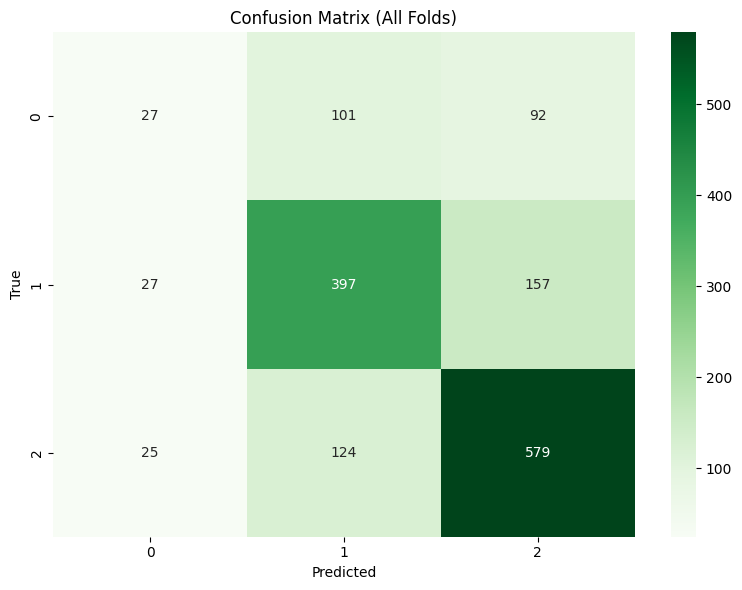

Cross-Validation Results (Accuracy):
  Fold 1: 66.01%
  Fold 2: 62.75%
  Fold 3: 67.65%
  Fold 4: 65.36%
  Fold 5: 66.23%


In [12]:
# https://www.geeksforgeeks.org/machine-learning/stratified-k-fold-cross-validation/
# gradient boosting machines
# builds decision trees in a serial fashion -- each tree is fit to the gradient of the loss function of the current stage's ensemble

kf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
metrics = []
all_y_true = []
all_y_pred = []

cust_params = {'objective':'multiclass',
          'metric':'multi_logloss',
          'boosting_type':'gbdt',
          'num_leaves':31,
          'max_depth':-1, # higher depth leads to overfitting
          'n_estimators':100,
          'learning_rate':0.03,
          'class_weight':'balanced',
          'min_data_in_leaf':2,
          'random_state':0,
          'num_class':3,
          'feature_fraction':1,
          'bagging_fraction':1,
          'verbosity':-1,
          'scoring':'f1_macro'}

fold_num = 1
for train_index, test_index in kf.split(X_imputed,y): # splits dataset into stratified train-test indices
    X_train, X_test = X_imputed.iloc[train_index], X_imputed.iloc[test_index] # features
    y_train, y_test = y.iloc[train_index], y.iloc[test_index] # labels
    
    # creation of lightgbm datasets
    train_lgb_data = lgb.Dataset(X_train, label=y_train)
    test_lgb_data = lgb.Dataset(X_test, label=y_test)

    lgb_model = lgb.train(params=cust_params, train_set=train_lgb_data, num_boost_round=100)
    
    y_pred = lgb_model.predict(X_test)
    y_pred_labels = np.argmax(y_pred, axis=1)

    accuracy = accuracy_score(y_test, y_pred_labels)
    print(fold_num, ': ',accuracy)
    fold_num += 1
    metrics.append(accuracy)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred_labels)

print(classification_report(all_y_true, all_y_pred, target_names=encoder.categories_[6]))
cm = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (All Folds)')
plt.tight_layout()
plt.show()
# # cross_val_results = cross_val_score(model, X, y_encoded, cv=kf, scoring ='accuracy')

print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(metrics, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

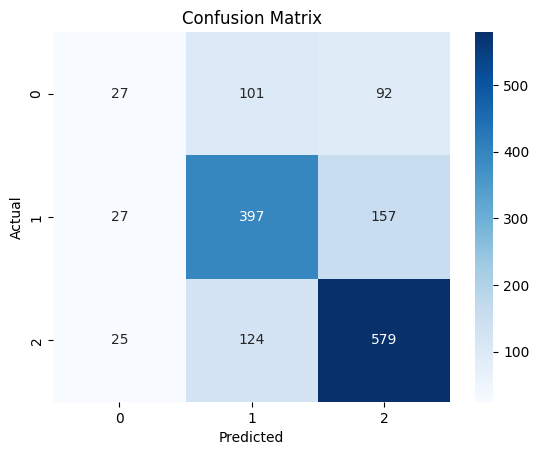

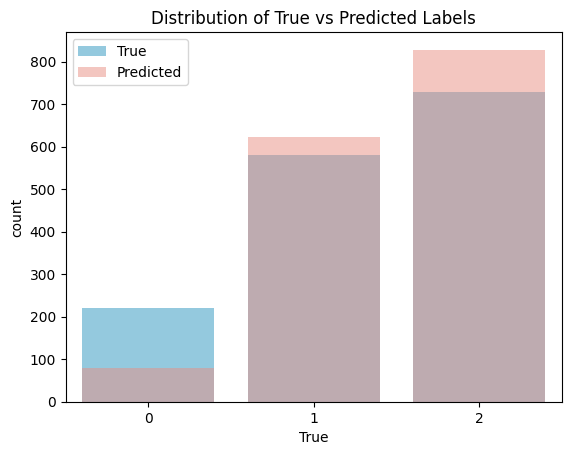

In [26]:
# graph visualization
def graph_vis(all_y_true,all_y_pred):
    cm = confusion_matrix(all_y_true, all_y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') # 'annot=True' displays the numbers, 'fmt="d"' ensures integer formatting
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    df_preds = pd.DataFrame({"True": [int(x) for x in all_y_true],
                            "Predicted": all_y_pred})

    sns.countplot(x="True", data=df_preds, label="True", color="skyblue")
    sns.countplot(x="Predicted", data=df_preds, label="Predicted", color="salmon", alpha=0.5)
    plt.legend()
    plt.title("Distribution of True vs Predicted Labels")
    plt.show()

graph_vis(all_y_true,all_y_pred)

XGBoost Model

1 :  0.6699346405228758
2 :  0.6372549019607843
3 :  0.6601307189542484
4 :  0.6405228758169934
5 :  0.6524590163934426
              precision    recall  f1-score   support

         LOW       0.29      0.14      0.19       220
INTERMEDIARY       0.64      0.69      0.66       581
        HIGH       0.71      0.77      0.74       728

    accuracy                           0.65      1529
   macro avg       0.55      0.53      0.53      1529
weighted avg       0.62      0.65      0.63      1529



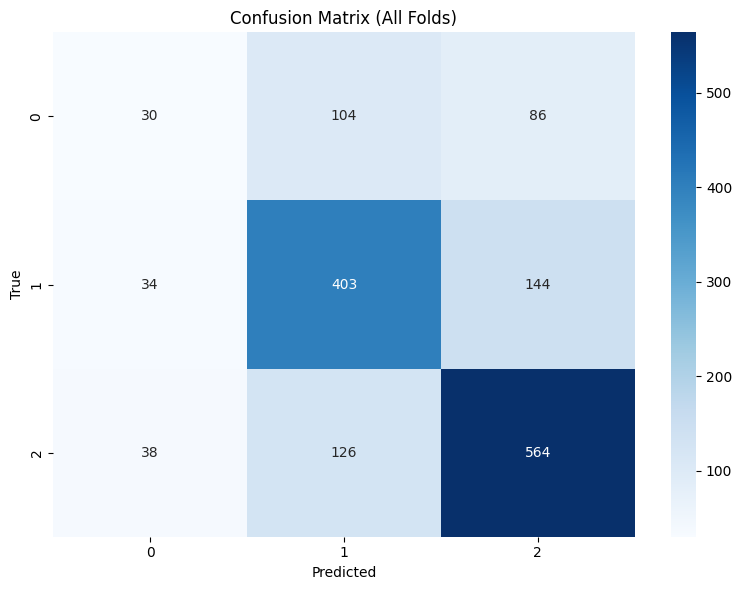

Cross-Validation Results (Accuracy):
  Fold 1: 66.99%
  Fold 2: 63.73%
  Fold 3: 66.01%
  Fold 4: 64.05%
  Fold 5: 65.25%


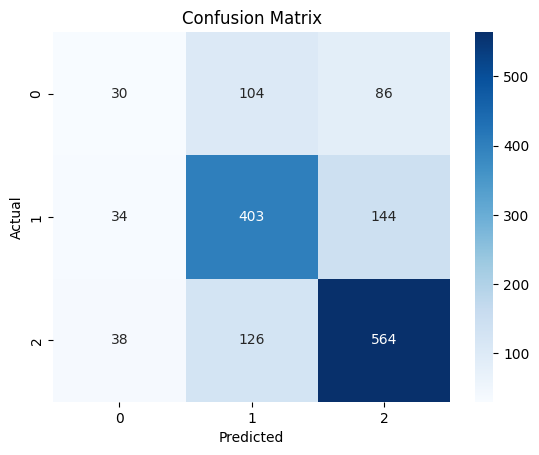

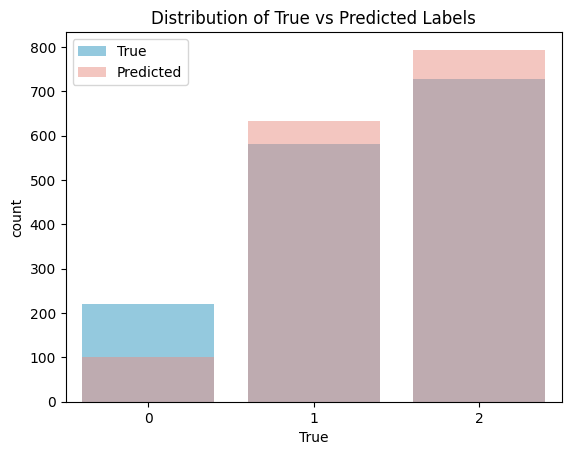

In [28]:
kf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
metrics = []
xgb_y_true = []
xgb_y_pred = []

fold_num = 1
for train_index, test_index in kf.split(X_imputed,y): # splits dataset into stratified train-test indices
    X_train, X_test = X_imputed.iloc[train_index], X_imputed.iloc[test_index] # features
    y_train, y_test = y.iloc[train_index], y.iloc[test_index] # labels
    
    xgb_model = xgb.XGBClassifier(objective='multi:softprob',num_class=3,eval_metric='mlogloss')
    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    print(fold_num, ': ',accuracy)
    fold_num += 1
    metrics.append(accuracy)
    xgb_y_true.extend(y_test)
    xgb_y_pred.extend(y_pred)

print(classification_report(xgb_y_true, xgb_y_pred, target_names=encoder.categories_[6]))
cm = confusion_matrix(xgb_y_true, xgb_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (All Folds)')
plt.tight_layout()
plt.show()

print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(metrics, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

graph_vis(xgb_y_true,xgb_y_pred)